# The eigensolver, and how fast this is

The SCF spends almost all of its time diagonalising, so the eigensolver is the whole
performance story. Forming `H` and calling `eigh` is `O(npw^3)` and `O(npw^2)` of memory;
a block Davidson gets the same eigenvalues to 1e-13 Ry at a fraction of the cost, and
with it pypresso runs **within 2-4x of serial Quantum ESPRESSO per SCF iteration**.

What is solved at every k-point is a *generalised* eigenproblem, because ultrasoft
and PAW make the overlap non-trivial:

$$\hat H\,|\psi_{n\mathbf k}\rangle
 = \varepsilon_{n\mathbf k}\,\hat S\,|\psi_{n\mathbf k}\rangle ,
\qquad
\hat S = 1 + \sum_{I,ij} q^I_{ij}\,|\beta^I_i\rangle\langle\beta^I_j|$$

Davidson never forms $\hat H$: it applies it to a block of vectors, adds the
preconditioned residuals $|r_n\rangle = (\hat H - \varepsilon_n \hat S)|\psi_n\rangle$
to the subspace, and diagonalises there.

Phases P4 and P10. Every timing here is single core — the only honest comparison against
a serial `pw.x`.

In [1]:
# XLA must be pinned before JAX is imported, so this comes first.
import os

os.environ["XLA_FLAGS"] = "--xla_cpu_multi_thread_eigen=false intra_op_parallelism_threads=1"
os.environ["OMP_NUM_THREADS"] = "1"

import time
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from pypresso import Calculator
from pypresso.scf.driver import run_scf
from pypresso.scf.potential import v_of_rho
from pypresso.solvers import davidson_eigensolver_all

BENCH, PSEUDO = Path("../benchmarks"), Path("../tests/data/pseudo")


def load(name):
    return Calculator.from_file(BENCH / name, pseudo_dir=PSEUDO, announce=False)


def timed(function, repeats=5):
    jax.block_until_ready(function())                    # the first call compiles
    start = time.perf_counter()
    for _ in range(repeats):
        value = jax.block_until_ready(function())
    return (time.perf_counter() - start) / repeats * 1e3, value


def exact_eigenpairs(hamiltonian, nbnd):
    """Form `H` and diagonalise: the answer Davidson has to reproduce.

    These ten lines live in the notebook and in ``tests/exact_reference.py``, never
    in the package -- an ``npw x npw`` matrix is exactly what an iterative solver
    exists to avoid, so there is no dense solver a run can select by name. Padded
    plane waves are pushed above the spectrum rather than deleted, to keep the
    static shape JAX needs.
    """
    matrix, mask = hamiltonian.matrix(0), hamiltonian.state_mask[0]
    shift = jnp.max(jnp.abs(matrix)) * 1000.0 + 1.0
    matrix = jnp.where(mask[:, None] & mask[None, :], matrix, 0.0)
    matrix = matrix + jnp.diag(jnp.where(mask, 0.0, shift))
    return jnp.linalg.eigh(matrix)[0][:nbnd]

## Davidson against the exact answer, and what it saves

Same Hamiltonian, both routes, at two cutoffs. The eigenvalues agree to 1e-13 Ry and the
gap in cost opens with the size of the basis, which is the entire point.

In [2]:
potential_of_rho = jax.jit(v_of_rho)
rows = []
for name in ("si-1k.in", "si-1k-ecut40.in"):
    calc = load(name)
    calculation = calc.calculation
    potential = potential_of_rho(calculation.starting_density(),
                                 calculation.basis.dense, calc.system.cell)
    h = calculation.hamiltonian(potential.v_scf)[0]        # one per spin channel

    exact_ms, exact = timed(lambda: exact_eigenpairs(h, 4), 3)
    dav_ms, dav = timed(
        lambda: davidson_eigensolver_all(h, 4, None, max_iterations=60), 3)
    agreement = np.abs(np.asarray(exact) - np.asarray(dav[0])[0]).max()
    rows.append((name, calculation.basis.npwx, exact_ms, dav_ms, agreement))
    print("  %-17s npw %5d   form H + eigh %8.1f ms   Davidson %6.1f ms  (%4.1fx)"
          "   agree to %.0e Ry" % (name, calculation.basis.npwx, exact_ms, dav_ms,
                                   exact_ms / dav_ms, agreement))

  si-1k.in          npw   180   form H + eigh     17.3 ms   Davidson   11.4 ms  ( 1.5x)   agree to 1e-13 Ry


  si-1k-ecut40.in   npw  1131   form H + eigh   1246.4 ms   Davidson   82.9 ms  (15.0x)   agree to 1e-13 Ry


## Asking for only as much accuracy as the density deserves

The second trap after the algorithm itself. `electrons.f90` schedules the diagonalisation
threshold `ethr` against the error in the density: an early iteration whose density is
wrong in the second decimal has nothing to gain from eigenvalues good to 1e-12. A fixed
tight threshold does about three times the eigensolver work for the same answer, and this
schedule is why `conv_thr` here means what it means in a `pw.x` input.

converged to 6.89e-11 Ry in 8 iterations


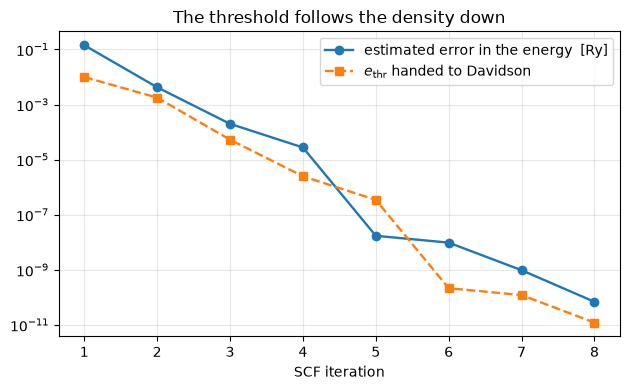

In [3]:
result = load("si-1k-ecut40.in").get_scf(conv_thr=1e-10)
history = result.history

fig, ax = plt.subplots(figsize=(6.4, 4))
iterations = [row["iteration"] for row in history]
ax.semilogy(iterations, [row["accuracy"] for row in history], "o-", lw=1.7,
            label="estimated error in the energy  [Ry]")
ax.semilogy(iterations, [row["ethr"] for row in history], "s--", lw=1.7,
            label=r"$e_{\rm thr}$ handed to Davidson")
ax.set_xlabel("SCF iteration"); ax.set_title("The threshold follows the density down")
ax.legend(); ax.grid(alpha=0.3, which="both"); fig.tight_layout()

print("converged to %.2e Ry in %d iterations" % (history[-1]["accuracy"], result.iterations))

## Two more things that were worth more than any micro-optimisation

**Symmetry.** Reducing an automatic k-grid to the irreducible wedge divides the work by
the number of operations that relate its points — 8 k-points to 2 on the cell below, for
the same energy to 1e-10 Ry. Nothing about the arithmetic got faster.

**Where the arrays are small, the cost is compilation, not flops.** Every JAX operation
dispatched outside a `jit` compiles separately at about 50 ms, so setup once spent 10 s
compiling 81 kernels to do 0.2 s of arithmetic. Optimising here means fewer compiled
units, which is the opposite of the instinct the Fortran encourages; the persistent cache
in `~/.cache/pypresso/jax` then removes most of what is left on the second run.

In [4]:
from pypresso.system.kpoints import KPoints
from pypresso.system.symmetry import find_symmetries

QE = Path("../quantum_espresso/qe-7.5-ReleasePack/qe-7.5/test-suite/pw_scf")
wedge = Calculator.from_file(QE / "scf-kauto.in", pseudo_dir=PSEUDO, announce=False)
# ``with_kpoints`` is not a thing: the unreduced grid is a different System, and a
# calculator is built on one. This is what the *derived* constructors exist for.
full = wedge.with_kpoints(
    KPoints.automatic((2, 2, 2), (1, 1, 1), wedge.system.cell))

print("  %d symmetry operations"
      % find_symmetries(wedge.system.cell, wedge.system.structure).nsym)
for label, variant in (("full grid", full), ("irreducible wedge", wedge)):
    # A timing has to defeat the cache the calculator exists to provide, so this
    # one cell calls the function underneath it. Everything fixed -- the basis,
    # the projectors, the symmetry -- is still built once, on the calculator.
    setup = variant.calculation
    run_once = lambda: run_scf(variant.system, variant.pseudos,
                               calculation=setup, conv_thr=1e-10)
    run = run_once()                                                  # compile
    best = min(timed(run_once, 1)[0] for _ in range(3))
    print("  %-18s %d k-points   %6.1f ms/iteration   E = %.9f Ry"
          % (label, variant.system.kpoints.nk, best / run.iterations, run.total_energy))

  48 symmetry operations


  full grid          8 k-points     22.6 ms/iteration   E = -15.794495571 Ry


  irreducible wedge  2 k-points     10.2 ms/iteration   E = -15.794495571 Ry


## Against Quantum ESPRESSO, single core

`tools/compare_qe.py` runs both codes on the same input — QE built serial, XLA pinned to
one thread — and reads QE's own timing report. Measured on this machine (not re-run here,
since it needs the vendored `pw.x`):

| | `si-1k` 2 atoms | `si-1k-ecut40` 2 atoms | `si8-1k-ecut30` 8 atoms | `si16-1k-ecut30` 16 atoms |
|---|---|---|---|---|
| plane waves | 180 | 1131 | 2950 | 5900 |
| QE, per SCF iteration | 0.003 s | 0.011 s | 0.071 s | 0.278 s |
| pypresso, per SCF iteration | 0.007 s | 0.033 s | 0.254 s | 1.141 s |
| ratio | **2.8x** | **3.0x** | **3.6x** | **4.1x** |
| total energy agreement | 7e-7 Ry | 3e-9 Ry | 4e-9 Ry | 1e-9 Ry |

The ratio drifts up with size, which says where the remaining work is: at sixteen atoms
the eigensolver is 84% of an iteration and `h_psi` is 71% of a Davidson step. Beyond that
the parallel axis is k-points — it leads every wavefunction-shaped array precisely so it
can be sharded across cores and GPUs, and none of that is switched on here.

---
**The detail:** `PERFORMANCE.md` (the full breakdown, what each change was worth, the
backlog) and `PLAN.md` §3 P4/P10 — including the two traps in transcribing `cegterg`.
**The tests:** `tests/unit/test_solvers.py`, `tests/regression/test_batching_scf.py`.